In [ ]:
# !pip install torch torchvision

In [ ]:
# pip uninstall torch torchvision -y

Found existing installation: torch 2.12.0
Uninstalling torch-2.12.0:
  Successfully uninstalled torch-2.12.0
Found existing installation: torchvision 0.27.0
Uninstalling torchvision-0.27.0:
  Successfully uninstalled torchvision-0.27.0
Note: you may need to restart the kernel to use updated packages.


2051 10000 28 28
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 116 125 171 255 255 150  93   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0 169 253 253 253 253 253 253 218  30
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 169 253 253 253 213 142 176 253 253 122
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0  52 250 253 210  32  12   0   6 206 253 140
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0  77 251 210  25   0   0   0 122 248 253  65
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  31  18   0  

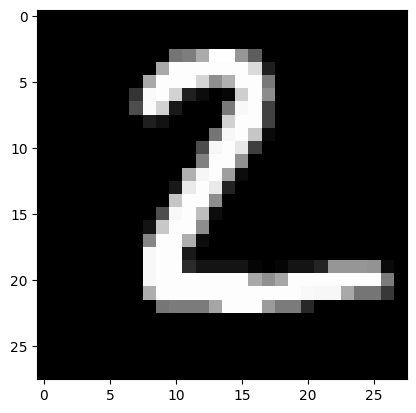

In [9]:
import struct
import numpy as np
import matplotlib.pyplot as plt

path = "data/MNIST/raw/t10k-images-idx3-ubyte"

with open(path, "rb") as f:
    magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
    images = np.frombuffer(f.read(), dtype=np.uint8)
    images = images.reshape(num, rows, cols)

print(magic, num, rows, cols)
print(images[1])
plt.imshow(images[1], cmap="gray")
plt.show()

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.nn import functional as F
import torchvision.datasets as datasets
from torch.utils.data import Subset
# ------------------------- 模型定义（与原 DemoModel 完全一致，仅修改注释） -------------------------
class DemoModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(16 * 16 * 16, 128)   # 32x32 -> pool -> 16x16
        self.dropout = nn.Dropout(p=0.5)
        self.bn = nn.BatchNorm1d(128)
        self.embedding = nn.Embedding(100, 32)    # 演示用，实际 forward 中未使用
        self.lstm = nn.LSTM(input_size=128, hidden_size=64, batch_first=True)
        self.attn = nn.MultiheadAttention(embed_dim=64, num_heads=4, batch_first=True)
        self.ln = nn.LayerNorm(64)
        self.fc_out = nn.Linear(64, 10)

    def forward(self, x):
        # 卷积块
        x = self.conv1(x)
        x = self.pool(x)
        x = self.relu(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.dropout(x)
        x = self.bn(x)
        # 扩展为序列（5个时间步）
        x = x.unsqueeze(1).expand(-1, 5, -1)
        lstm_out, _ = self.lstm(x)
        x = lstm_out[:, -1, :]           # 取最后时间步
        # 注意力演示
        seq_len = 4
        q = x.unsqueeze(1).expand(-1, seq_len, -1)
        k, v = q, q
        attn_out, _ = self.attn(q, k, v)
        x = attn_out.mean(dim=1)         # 池化
        x = self.ln(x)
        out = self.fc_out(x)
        return out

# ------------------------- 数据预处理 -------------------------
# MNIST 原始尺寸 28x28，单通道。
# 为了适配模型，做如下变换：
# 1. 将图像缩放到 32x32
# 2. 将单通道复制成 3 通道（ToTensor 后是 [0,1]，然后 repeat）
transform = transforms.Compose([
    transforms.Resize((32, 32)),               # 缩放到 32x32
    transforms.ToTensor(),                     # 变成 [1,32,32] 范围 [0,1]
    transforms.Lambda(lambda x: x.repeat(3, 1, 1))   # 重复 3 次得到 [3,32,32]
])

full_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# 前 50% 作为训练集，后 50% 作为测试集
n = len(full_dataset)          # 60000
split = n // 2                 # 30000
train_dataset = Subset(full_dataset, range(0, split))
test_dataset  = Subset(full_dataset, range(split, n))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

# ------------------------- 训练设置 -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DemoModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ------------------------- 训练循环 -------------------------
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * images.size(0)
    
    avg_loss = total_loss / len(train_loader.dataset)
    
    # 验证
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100.0 * correct / total
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f} | Test Accuracy: {accuracy:.2f}%")

Epoch 1/5 | Loss: 0.3532 | Test Accuracy: 96.37%
Epoch 2/5 | Loss: 0.1389 | Test Accuracy: 97.19%
Epoch 3/5 | Loss: 0.1103 | Test Accuracy: 97.81%
Epoch 4/5 | Loss: 0.0854 | Test Accuracy: 97.61%
Epoch 5/5 | Loss: 0.0778 | Test Accuracy: 98.03%


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.nn import functional as F
import torchvision.datasets as datasets
from torch.utils.data import Subset
# ------------------------- 模型定义（与原 DemoModel 完全一致，仅修改注释） -------------------------
class DemoModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(16 * 16 * 16, 128)   # 32x32 -> pool -> 16x16
        self.dropout = nn.Dropout(p=0.5)
        self.bn = nn.BatchNorm1d(128)
        self.embedding = nn.Embedding(100, 32)    # 演示用，实际 forward 中未使用
        self.lstm = nn.LSTM(input_size=128, hidden_size=64, batch_first=True)
        # self.attn = nn.MultiheadAttention(embed_dim=64, num_heads=4, batch_first=True)
        self.ln = nn.LayerNorm(64)
        self.fc_out = nn.Linear(64, 10)

    def forward(self, x):
        # 卷积块
        x = self.conv1(x)
        x = self.pool(x)
        # x = self.relu(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.dropout(x)
        x = self.bn(x)
        # 扩展为序列（5个时间步）
        x = x.unsqueeze(1).expand(-1, 5, -1)
        lstm_out, _ = self.lstm(x)
        x = lstm_out[:, -1, :]           # 取最后时间步
        # 注意力演示
        seq_len = 4
        q = x.unsqueeze(1).expand(-1, seq_len, -1)
        k, v = q, q
        # attn_out, _ = self.attn(q, k, v)
        # x = attn_out.mean(dim=1)         # 池化
        # x = self.ln(x)
        out = self.fc_out(x)
        return out

# ------------------------- 数据预处理 -------------------------
# MNIST 原始尺寸 28x28，单通道。
# 为了适配模型，做如下变换：
# 1. 将图像缩放到 32x32
# 2. 将单通道复制成 3 通道（ToTensor 后是 [0,1]，然后 repeat）
transform = transforms.Compose([
    transforms.Resize((32, 32)),               # 缩放到 32x32
    transforms.ToTensor(),                     # 变成 [1,32,32] 范围 [0,1]
    transforms.Lambda(lambda x: x.repeat(3, 1, 1))   # 重复 3 次得到 [3,32,32]
])

full_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# 前 50% 作为训练集，后 50% 作为测试集
n = len(full_dataset)          # 60000
split = n // 2                 # 30000
train_dataset = Subset(full_dataset, range(0, split))
test_dataset  = Subset(full_dataset, range(split, n))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

# ------------------------- 训练设置 -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DemoModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ------------------------- 训练循环 -------------------------
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * images.size(0)
    
    avg_loss = total_loss / len(train_loader.dataset)
    
    # 验证
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100.0 * correct / total
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f} | Test Accuracy: {accuracy:.2f}%")

Epoch 1/5 | Loss: 0.5125 | Test Accuracy: 94.33%
Epoch 2/5 | Loss: 0.2070 | Test Accuracy: 96.21%
Epoch 3/5 | Loss: 0.1601 | Test Accuracy: 96.45%
Epoch 4/5 | Loss: 0.1442 | Test Accuracy: 96.03%
Epoch 5/5 | Loss: 0.1249 | Test Accuracy: 96.60%


In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DemoModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        # 1. 卷积层 + 池化层 (适用于4D输入: batch, channels, height, width)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # 2. 激活层 (通常放在卷积/线性之后)
        self.relu = nn.ReLU()
        
        # 3. 展平层 (从卷积特征图转为向量)
        self.flatten = nn.Flatten()
        
        # 4. 线性层 (全连接)
        self.fc1 = nn.Linear(16 * 16 * 16, 128)  # 假设输入图像 32x32，经过一次池化变成16x16
        
        # 5. Dropout (正则化)
        self.dropout = nn.Dropout(p=0.5)
        
        # 6. 归一化层 (BatchNorm1d 作用于特征维度)
        self.bn = nn.BatchNorm1d(128)
        
        # 7. 嵌入层 (需要整数索引，后续会单独演示)
        self.embedding = nn.Embedding(num_embeddings=100, embedding_dim=32)
        
        # 8. 循环层 (LSTM, 输入需要 3D: seq_len, batch, features)
        self.lstm = nn.LSTM(input_size=128, hidden_size=64, batch_first=True)
        
        # 9. Transformer 层 (MultiheadAttention)
        self.attn = nn.MultiheadAttention(embed_dim=64, num_heads=4, batch_first=True)
        
        # 10. 层归一化 (LayerNorm)
        self.ln = nn.LayerNorm(64)
        
        # 11. 输出线性层
        self.fc_out = nn.Linear(64, 10)
        
    def forward(self, x):
        # 为了能经过不同类型的层，我们需要动态调整 x 的形状和数据类型
        # 假设输入 x 是一个字典，包含图像和序列两部分，但为了简单，我们统一从一个随机输入开始
        # 这里演示一个串行流程，通过 reshape/view 来适配各层需求
        
        print(f"初始输入形状: {x.shape}")
        
        # ---------- 卷积 + 池化 部分 (需要4D输入) ----------
        # 假设 x 是 (batch, 3, 32, 32)
        x = self.conv1(x)
        print(f"conv1 输出形状: {x.shape}")
        x = self.pool(x)
        print(f"pool 输出形状: {x.shape}")
        x = self.relu(x)
        
        # 展平
        x = self.flatten(x)
        print(f"flatten 输出形状: {x.shape}")
        
        # 线性层
        x = self.fc1(x)
        print(f"fc1 输出形状: {x.shape}")
        
        # Dropout (训练时随机失活，形状不变)
        x = self.dropout(x)
        # BatchNorm
        x = self.bn(x)
        print(f"bn 输出形状: {x.shape}")
        
        # ---------- LSTM 部分 (需要 3D: batch, seq_len, features) ----------
        # 当前 x 是 (batch, 128)，我们将其扩展为序列长度2
        x = x.unsqueeze(1)          # (batch, 1, 128)
        x = x.expand(-1, 5, -1)     # (batch, 5, 128) 重复5份模拟序列
        print(f"扩展为序列后形状: {x.shape}")
        lstm_out, (hn, cn) = self.lstm(x)
        print(f"LSTM 输出形状: {lstm_out.shape}")  # (batch, seq_len, hidden_size=64)
        
        # 取最后一个时间步的输出
        x = lstm_out[:, -1, :]      # (batch, 64)
        print(f"取最后时间步: {x.shape}")
        
        # ---------- Transformer MultiheadAttention 需要 query, key, value ----------
        # 为演示注意力，我们创建三个相同的张量 (batch, seq_len, 64)
        seq_len = 4
        q = x.unsqueeze(1).expand(-1, seq_len, -1)   # (batch, seq_len, 64)
        k = q.clone()
        v = q.clone()
        attn_out, attn_weights = self.attn(q, k, v)
        print(f"MultiheadAttention 输出形状: {attn_out.shape}")
        
        # 取平均或展平
        x = attn_out.mean(dim=1)   # (batch, 64)
        print(f"注意力池化后: {x.shape}")
        
        # LayerNorm
        x = self.ln(x)
        print(f"LayerNorm 输出: {x.shape}")
        
        # 最终输出层
        out = self.fc_out(x)
        print(f"最终输出形状: {out.shape}")
        
        return out
    
    # 单独演示 Embedding 层 (因为需要整数输入，不与主流程混合)
    def embedding_demo(self, indices):
        # indices: (batch, seq_len) 的整数张量
        emb = self.embedding(indices)
        print(f"Embedding 输入形状: {indices.shape}, 输出形状: {emb.shape}")
        return emb

# ================= 测试 =================
if __name__ == "__main__":
    model = DemoModel()
    
    # 创建一个模拟图像输入: batch=2, 3通道, 32x32
    dummy_image = torch.randn(2, 3, 32, 32)
    print("\n=== 主流程前向传播 ===")
    output = model(dummy_image)
    
    print("\n=== Embedding 演示 ===")
    dummy_indices = torch.randint(0, 100, (2, 10))  # batch=2, 序列长度=10
    model.embedding_demo(dummy_indices)


=== 主流程前向传播 ===
初始输入形状: torch.Size([2, 3, 32, 32])
conv1 输出形状: torch.Size([2, 16, 32, 32])
pool 输出形状: torch.Size([2, 16, 16, 16])
flatten 输出形状: torch.Size([2, 4096])
fc1 输出形状: torch.Size([2, 128])
bn 输出形状: torch.Size([2, 128])
扩展为序列后形状: torch.Size([2, 5, 128])
LSTM 输出形状: torch.Size([2, 5, 64])
取最后时间步: torch.Size([2, 64])
MultiheadAttention 输出形状: torch.Size([2, 4, 64])
注意力池化后: torch.Size([2, 64])
LayerNorm 输出: torch.Size([2, 64])
最终输出形状: torch.Size([2, 10])

=== Embedding 演示 ===
Embedding 输入形状: torch.Size([2, 10]), 输出形状: torch.Size([2, 10, 32])


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DemoModel(nn.Module):
    """
    演示模型：包含 CNN、RNN、Transformer、归一化、Dropout、Embedding 等典型层。
    目的：观察数据经过不同层时的形状变化和维度变换逻辑。
    注意：本模型仅为教学示例，无实际应用价值。
    """

    def __init__(self):
        super().__init__()
        
        # ------------------------------------------------------------
        # 1. 卷积层 Conv2d
        # ------------------------------------------------------------
        # in_channels=3   : 输入图像的通道数（RGB 图像为 3）
        # out_channels=16 : 卷积核的数量，即输出特征图的通道数
        # kernel_size=3   : 卷积核的大小，这里是 3x3
        # padding=1       : 在输入周围填充 1 圈 0，使得输出高度/宽度与输入相同（stride=1 时）
        # 注意：默认 stride=1，dilation=1，bias=True
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        
        # 最大池化层
        # kernel_size=2 : 池化窗口 2x2
        # stride=2      : 窗口每次移动 2 步，因此特征图的尺寸减半
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # 激活层（ReLU 不改变形状）
        self.relu = nn.ReLU()
        
        # ------------------------------------------------------------
        # 2. 展平层 Flatten
        # ------------------------------------------------------------
        # 将多维特征图（batch, channels, height, width）展平为向量 (batch, channels*height*width)
        self.flatten = nn.Flatten()
        
        # ------------------------------------------------------------
        # 3. 全连接层 Linear（线性层）
        # ------------------------------------------------------------
        # in_features=16*16*16 : 输入特征数（假设输入图像 32x32，经过一次池化变为 16x16，通道数为16）
        # out_features=128     : 输出特征维度
        self.fc1 = nn.Linear(in_features=16 * 16 * 16, out_features=128)
        
        # ------------------------------------------------------------
        # 4. Dropout 层（随机失活）
        # ------------------------------------------------------------
        # p=0.5 : 每个神经元以 50% 概率被置为 0（训练时），测试时不变。
        # 不改变形状
        self.dropout = nn.Dropout(p=0.5)
        
        # ------------------------------------------------------------
        # 5. 批归一化层 BatchNorm1d
        # ------------------------------------------------------------
        # num_features=128 : 输入特征的维度（即全连接层输出的特征数量）
        # 对每个特征维度独立计算均值和方差，然后归一化。可加快收敛。
        # 不改变形状
        self.bn = nn.BatchNorm1d(num_features=128)
        
        # ------------------------------------------------------------
        # 6. 嵌入层 Embedding
        # ------------------------------------------------------------
        # num_embeddings=100 : 词表大小（或离散值总数），索引范围 [0, 99]
        # embedding_dim=32   : 每个索引映射成的稠密向量长度
        # 输入：整数张量，形状任意；输出：最后增加一个 embedding_dim 维度
        self.embedding = nn.Embedding(num_embeddings=100, embedding_dim=32)
        
        # ------------------------------------------------------------
        # 7. LSTM 层（长短时记忆网络）
        # ------------------------------------------------------------
        # input_size=128   : 每个时间步输入的特征数（即 fc1 输出的维度）
        # hidden_size=64   : LSTM 隐藏状态 h 和 c 的维度
        # batch_first=True : 输入张量的形状约定为 (batch, seq_len, input_size)
        #                    而不是默认的 (seq_len, batch, input_size)
        self.lstm = nn.LSTM(input_size=128, hidden_size=64, batch_first=True)
        
        # ------------------------------------------------------------
        # 8. 多头注意力层 MultiheadAttention
        # ------------------------------------------------------------
        # embed_dim=64     : 输入和输出的特征维度（必须与 LSTM 输出的 hidden_size 一致）
        # num_heads=4      : 并行注意力的头数，embed_dim 必须能被 num_heads 整除
        # batch_first=True : 输入形状 (batch, seq_len, embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim=64, num_heads=4, batch_first=True)
        
        # ------------------------------------------------------------
        # 9. 层归一化 LayerNorm
        # ------------------------------------------------------------
        # normalized_shape=64 : 归一化的特征维度（通常最后一维的大小）
        # 对每个样本的最后一维做归一化，适用于 RNN/Transformer 输出。
        self.ln = nn.LayerNorm(normalized_shape=64)
        
        # ------------------------------------------------------------
        # 10. 输出线性层
        # ------------------------------------------------------------
        # in_features=64, out_features=10 : 将 64 维特征映射到 10 类（分类任务）
        self.fc_out = nn.Linear(in_features=64, out_features=10)
        
    def forward(self, x):
        """
        参数 x : 假设是图像输入，形状 (batch_size, 3, 32, 32)
        返回   : 分类 logits，形状 (batch_size, 10)
        """
        print(f"初始输入形状: {x.shape}")      # 期望 (2,3,32,32)
        
        # ---------- 卷积块 ----------
        x = self.conv1(x)
        # conv1 输出: (batch, out_channels, H, W) = (2,16,32,32)，因为 padding=1 保持 H,W
        print(f"conv1 输出形状: {x.shape}")
        
        x = self.pool(x)
        # MaxPool2d(kernel=2,stride=2) 将 H,W 减半: (2,16,16,16)
        print(f"pool 输出形状: {x.shape}")
        
        x = self.relu(x)   # 形状不变
        
        # 展平
        x = self.flatten(x)
        # 形状: (2, 16*16*16) = (2, 4096)
        print(f"flatten 输出形状: {x.shape}")
        
        # 全连接层
        x = self.fc1(x)    # (2,4096) -> (2,128)
        print(f"fc1 输出形状: {x.shape}")
        
        # Dropout (仅训练时有效，此处为了演示形状)
        x = self.dropout(x)
        # BatchNorm
        x = self.bn(x)      # 形状不变 (2,128)
        print(f"bn 输出形状: {x.shape}")
        
        # ---------- 为 LSTM 准备序列数据 ----------
        # 当前 x 是 (batch, 128)，LSTM 需要 (batch, seq_len, input_size)
        # 我们创建一个长度为 5 的虚拟序列：将每个样本重复 5 次
        x = x.unsqueeze(1)           # (2,1,128)
        x = x.expand(-1, 5, -1)      # (2,5,128)   -1 表示保持原大小
        print(f"扩展为序列后形状: {x.shape}")
        
        # LSTM 前向
        lstm_out, (hn, cn) = self.lstm(x)
        # lstm_out: (batch, seq_len, hidden_size) = (2,5,64)
        # hn: (num_layers*num_directions, batch, hidden_size) = (1,2,64)
        print(f"LSTM 输出形状: {lstm_out.shape}")
        
        # 取最后一个时间步的输出
        x = lstm_out[:, -1, :]       # (2,64)
        print(f"取最后时间步: {x.shape}")
        
        # ---------- 多头注意力演示 ----------
        # 注意力需要 query, key, value 三个张量，通常 shape 为 (batch, seq_len, embed_dim)
        # 为演示，我们基于当前 x 构造一个长度为 4 的序列
        seq_len = 4
        q = x.unsqueeze(1).expand(-1, seq_len, -1)   # (2,4,64)
        k = q.clone()   # 通常 key 和 value 可以是不同的，这里简单相同
        v = q.clone()
        
        attn_out, attn_weights = self.attn(q, k, v)
        # attn_out: (2,4,64) 形状与 q 相同
        # attn_weights: (2,4,4) 注意力权重矩阵
        print(f"MultiheadAttention 输出形状: {attn_out.shape}")
        
        # 池化或取平均以得到固定长度向量
        x = attn_out.mean(dim=1)     # 沿序列维度平均 -> (2,64)
        print(f"注意力池化后: {x.shape}")
        
        # 层归一化
        x = self.ln(x)               # (2,64)
        print(f"LayerNorm 输出: {x.shape}")
        
        # 最终分类
        out = self.fc_out(x)         # (2,10)
        print(f"最终输出形状: {out.shape}")
        return out
    
    def embedding_demo(self, indices):
        """
        单独演示 Embedding 层，因为它的输入是整数索引，不与其他层混合。
        indices : 形状 (batch, seq_len) 的 LongTensor，值在 [0, num_embeddings-1] 内
        """
        emb = self.embedding(indices)   # 输出形状 (batch, seq_len, embedding_dim)
        print(f"Embedding 输入形状: {indices.shape}, 输出形状: {emb.shape}")
        return emb


# ================= 测试代码 =================
if __name__ == "__main__":
    model = DemoModel()
    
    # 创建模拟图像输入：batch=2，3通道，高度32，宽度32
    dummy_image = torch.randn(2, 3, 32, 32)
    print("\n=== 主流程前向传播 ===")
    output = model(dummy_image)
    
    print("\n=== Embedding 演示 ===")
    dummy_indices = torch.randint(0, 100, (2, 10))   # batch=2, 序列长度=10
    model.embedding_demo(dummy_indices)


=== 主流程前向传播 ===
初始输入形状: torch.Size([2, 3, 32, 32])
conv1 输出形状: torch.Size([2, 16, 32, 32])
pool 输出形状: torch.Size([2, 16, 16, 16])
flatten 输出形状: torch.Size([2, 4096])
fc1 输出形状: torch.Size([2, 128])
bn 输出形状: torch.Size([2, 128])
扩展为序列后形状: torch.Size([2, 5, 128])
LSTM 输出形状: torch.Size([2, 5, 64])
取最后时间步: torch.Size([2, 64])
MultiheadAttention 输出形状: torch.Size([2, 4, 64])
注意力池化后: torch.Size([2, 64])
LayerNorm 输出: torch.Size([2, 64])
最终输出形状: torch.Size([2, 10])

=== Embedding 演示 ===
Embedding 输入形状: torch.Size([2, 10]), 输出形状: torch.Size([2, 10, 32])
